# OTF Scan --- Diagnostics & Manifest

Load scan dumps, apply fftshift + DC masking + RFI flagging,
inspect outlier dumps, pointing quality, survey coverage,
and update the survey manifest.

See `02_scan_load.ipynb` for frequency-switched spectra and HI maps.

In [1]:
import sys; sys.path.insert(0, '..')

import importlib
if 'utils' in sys.modules:
    del sys.modules['utils']
sys.path.insert(0, '.')

import ugradiolab.plotting as plotting
from ugradiolab.plotting import SS_FINE
from utils import (flag_rfi_channels, flag_outlier_dumps, vlsr_correction,
                   compute_R_for_dumps, compute_cell_W)
from plotters import plot_heatmap

from pathlib import Path
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
import re
import math
import warnings
import astropy.coordinates as ac
import astropy.units as u_ast
from astropy.time import Time as AstroTime
from collections import defaultdict

SAMPLE_RATE_HZ = 2.56e6
NFFT = 1024
HI_REST_MHZ = 1420.405
C_KMS = 299792.458

%matplotlib inline

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Load, fftshift, mask DC, RFI flag, outlier filter

In [2]:
STREAMING_DIR = Path('../../../data/lab04/streaming')

scan_dirs = []
for session_dir in sorted(STREAMING_DIR.glob('session_*')):
    found = sorted(session_dir.glob('obs_*'))
    print(f'{session_dir.name}: {len(found)} obs cells')
    scan_dirs.extend(found)

print(f'Total: {len(scan_dirs)} obs cells')

records = []
for d in scan_dirs:
    session_label = d.parent.name
    for p in sorted(d.glob('*.npz')):
        with np.load(p, allow_pickle=True) as f:
            records.append({
                'path': p,
                'session': session_label,
                'target': str(f['target_name']),
                'corr00': f['corr00'].astype(float),
                'corr11': f['corr11'].astype(float),
                'lo_mhz': float(f['lo_freq_mhz']),
                'noise_on': bool(f['noise_on']),
                'time': float(f['time']),
                'alt': float(f['alt_deg']),
                'az': float(f['az_deg']),
                'ra': float(f['ra_deg']),
                'dec': float(f['dec_deg']),
            })

N = len(records)
print(f'{N} total dumps loaded')

# Extract galactic coordinates directly from target_name (obs_{l}_{b} format)
for r in records:
    m = re.match(r'(?:obs|cal)_(-?\d+)_(-?\d+)', r['target'])
    if m:
        r['gl'] = int(m.group(1))
        r['gb'] = int(m.group(2))
    else:
        r['gl'] = None
        r['gb'] = None

sessions = sorted(set(r['session'] for r in records))


session_001: 153 obs cells
session_002: 14 obs cells
session_003: 95 obs cells
session_004: 67 obs cells
session_005: 19 obs cells
session_006: 97 obs cells
session_007: 80 obs cells
session_008: 75 obs cells
session_009: 153 obs cells
session_010: 40 obs cells
session_011: 32 obs cells
session_012: 241 obs cells
session_013: 17 obs cells
session_014: 77 obs cells
session_015: 7 obs cells
session_016: 26 obs cells
session_017: 4 obs cells
session_018: 101 obs cells
session_019: 4 obs cells
session_020: 1 obs cells
session_021: 17 obs cells
session_022: 4 obs cells
session_023: 15 obs cells
session_024: 3 obs cells
session_025: 3 obs cells
session_026: 51 obs cells
session_027: 169 obs cells
session_029: 2 obs cells
session_030: 7 obs cells
session_031: 15 obs cells
session_032: 5 obs cells
session_033: 3 obs cells
session_034: 33 obs cells
session_035: 12 obs cells
session_036: 0 obs cells
Total: 1642 obs cells
13314 total dumps loaded


In [3]:
# --- fftshift + mask DC + RFI flagging ---
DC_BIN = NFFT // 2

for r in records:
    r['corr00'] = np.fft.fftshift(r['corr00'])
    r['corr11'] = np.fft.fftshift(r['corr11'])

    r['corr00'][DC_BIN] = np.nan
    r['corr11'][DC_BIN] = np.nan

    if r['lo_mhz'] == 1420.0:
        for ch in [DC_BIN - 2, DC_BIN - 1]:
            r['corr00'][ch] = np.nan
            r['corr11'][ch] = np.nan

    r['stokes_I'] = r['corr00'] + r['corr11']

RFI_WINDOW = 15
RFI_SIGMA = 5.0
n_flagged = sum(flag_rfi_channels(r['stokes_I'], RFI_WINDOW, RFI_SIGMA)
                for r in records)
print(f'RFI flagged: {n_flagged} samples across {N} dumps')

# --- Outlier dump filter ---
SHAPE_DEV_THRESH = 0.10
SHAPE_FRAC_THRESH = 0.20

outlier_records = flag_outlier_dumps(records, SHAPE_DEV_THRESH, SHAPE_FRAC_THRESH)
n_outlier_removed = len(outlier_records)
N = len(records)

print(f'Outlier dump filter: removed {n_outlier_removed} dumps')
print(f'Remaining: {N} dumps')

RFI flagged: 1146347 samples across 13314 dumps
Outlier dump filter: removed 25 dumps
Remaining: 13289 dumps


## 2. Frequency switching + Neighbor QA

Compute frequency-switched spectra and flag cells whose W or peak velocity
deviates from the beam-weighted local plane of their neighbors.

In [4]:
# --- Frequency switching + LSR correction ---
EDGE_TRIM_MHZ = 0.256

lo_unique = sorted(set(r['lo_mhz'] for r in records if not r['noise_on']))
lo1, lo2 = lo_unique[0], lo_unique[1]
f_bb_mhz = np.fft.fftshift(np.fft.fftfreq(NFFT, d=1.0/SAMPLE_RATE_HZ)) / 1e6
f_sky = lo1 + f_bb_mhz
f_sky_2 = lo2 + f_bb_mhz
f_overlap_lo = max(f_sky[0], f_sky_2[0]) + EDGE_TRIM_MHZ
f_overlap_hi = min(f_sky[-1], f_sky_2[-1]) - EDGE_TRIM_MHZ
overlap_mask = (f_sky >= f_overlap_lo) & (f_sky <= f_overlap_hi)
f_overlap = f_sky[overlap_mask]
v_overlap = C_KMS * (1 - f_overlap / HI_REST_MHZ)

print(f'LO pair: ({lo1}, {lo2}) MHz')
print(f'Overlap: [{f_overlap_lo:.2f}, {f_overlap_hi:.2f}] MHz, {overlap_mask.sum()} channels')

# Galactic coords already parsed from target_name in cell 3.
# LSR corrections per (session, cell).
for r in records:
    if r.get('gl') is None or r['noise_on']:
        r['v_corr_lsr'] = 0.0
        continue

cell_session_groups = defaultdict(list)
for r in records:
    if r.get('gl') is not None and not r['noise_on']:
        cell_session_groups[(r['session'], r['gl'], r['gb'])].append(r)

for key, group in cell_session_groups.items():
    r0 = group[0]
    mean_t = np.mean([r['time'] for r in group])
    v_corr = vlsr_correction(r0['ra'], r0['dec'], mean_t)
    for r in group:
        r['v_corr_lsr'] = v_corr

# Common LSR velocity grid
v_lsr_lo = v_overlap[-1] + np.median([r['v_corr_lsr'] for r in records
                                       if r.get('gl') is not None and not r['noise_on']])
v_lsr_hi = v_overlap[0] + np.median([r['v_corr_lsr'] for r in records
                                      if r.get('gl') is not None and not r['noise_on']])
dv_kms = np.abs(np.median(np.diff(v_overlap)))
v_lsr_overlap = np.arange(v_lsr_lo, v_lsr_hi, dv_kms)

# Frequency-switch each cell, combine across sessions.
cell_results_combined = {}
all_cells = defaultdict(list)
for r in records:
    if r.get('gl') is not None and not r['noise_on']:
        all_cells[(r['gl'], r['gb'])].append(r)

for (gl, gb), dumps in all_cells.items():
    result = compute_R_for_dumps(
        dumps, lo1, lo2, overlap_mask, v_overlap,
        v_lsr_grid=v_lsr_overlap, lsr_correct=True,
    )
    if result is not None:
        cell_results_combined[(gl, gb)] = result

print(f'{len(cell_results_combined)} cells with freq-switched spectra')

LO pair: (1420.0, 1421.0) MHz
Overlap: [1419.98, 1421.02] MHz, 418 channels


/home/ikaros/projects/ay-121/labs/04/notebooks/utils/freqswitch.py:70: RuntimeWarning: Mean of empty slice
  R_sess = np.nanmean(R_pairs, axis=0)
/home/ikaros/projects/ay-121/labs/04/notebooks/utils/freqswitch.py:95: RuntimeWarning: Mean of empty slice
  R_mean = np.nanmean(R_all, axis=0)


1583 cells with freq-switched spectra


In [5]:
# # Snapshot per-session spectra before session QA modifies them
# session_qa_originals = {}
# for (gl, gb), cr in cell_results_combined.items():
#     R_per = cr.get('R_per_session')
#     labels = cr.get('session_labels')
#     if R_per is not None and len(R_per) >= 2:
#         session_qa_originals[(gl, gb)] = {
#             'R_per_session': [r.copy() for r in R_per],
#             'session_labels': list(labels) if labels else None,
#         }
# print(f'Saved originals for {len(session_qa_originals)} multi-session cells')

Neighbor diagnostics: 1583 cells
  Using the overlap window with 417 channels and dv=0.528 km/s
  Neighborhood: cells within 4.5 deg, min neighbors=5
  Beam weight: Gaussian overlap with HPBW=3.4 deg
  Thresholds: |dW/W_local| > 30% and |z_W| > 3.5; |dv_peak| > 15 km/s and |z_v| > 4.0
  Flags: W=15, peak_v=5, any=20
  Most deviant cells:
    l=125 b=  1 W=+37.318 (frac=+0.19, z=+2.63) v_peak=-56.6 km/s (dv=-40.8, z=-10.02) n=33
    l=208 b=  0 W=+30.307 (frac=+0.05, z=+0.39) v_peak=+41.6 km/s (dv=+25.5, z=+7.91) n=36
    l=123 b=  1 W=+37.725 (frac=+0.19, z=+3.39) v_peak=-55.5 km/s (dv=-38.5, z=-5.57) n=34
    l=115 b= -1 W=+36.661 (frac=+0.05, z=+1.44) v_peak=-47.1 km/s (dv=-15.3, z=-5.10) n=54
    l=218 b=  2 W=+19.426 (frac=-0.03, z=-0.42) v_peak=+47.4 km/s (dv=+21.3, z=+4.65) n=32
    l=213 b= -3 W=+20.738 (frac=-0.30, z=-5.41) v_peak=+52.7 km/s (dv=+30.3, z=+2.26) n=24
    l=266 b= 24 W=+16.899 (frac=+2.05, z=+39.42) v_peak=-3.3 km/s (dv=+0.9, z=+0.30) n=15
    l= 12 b= -4 W=+14.1

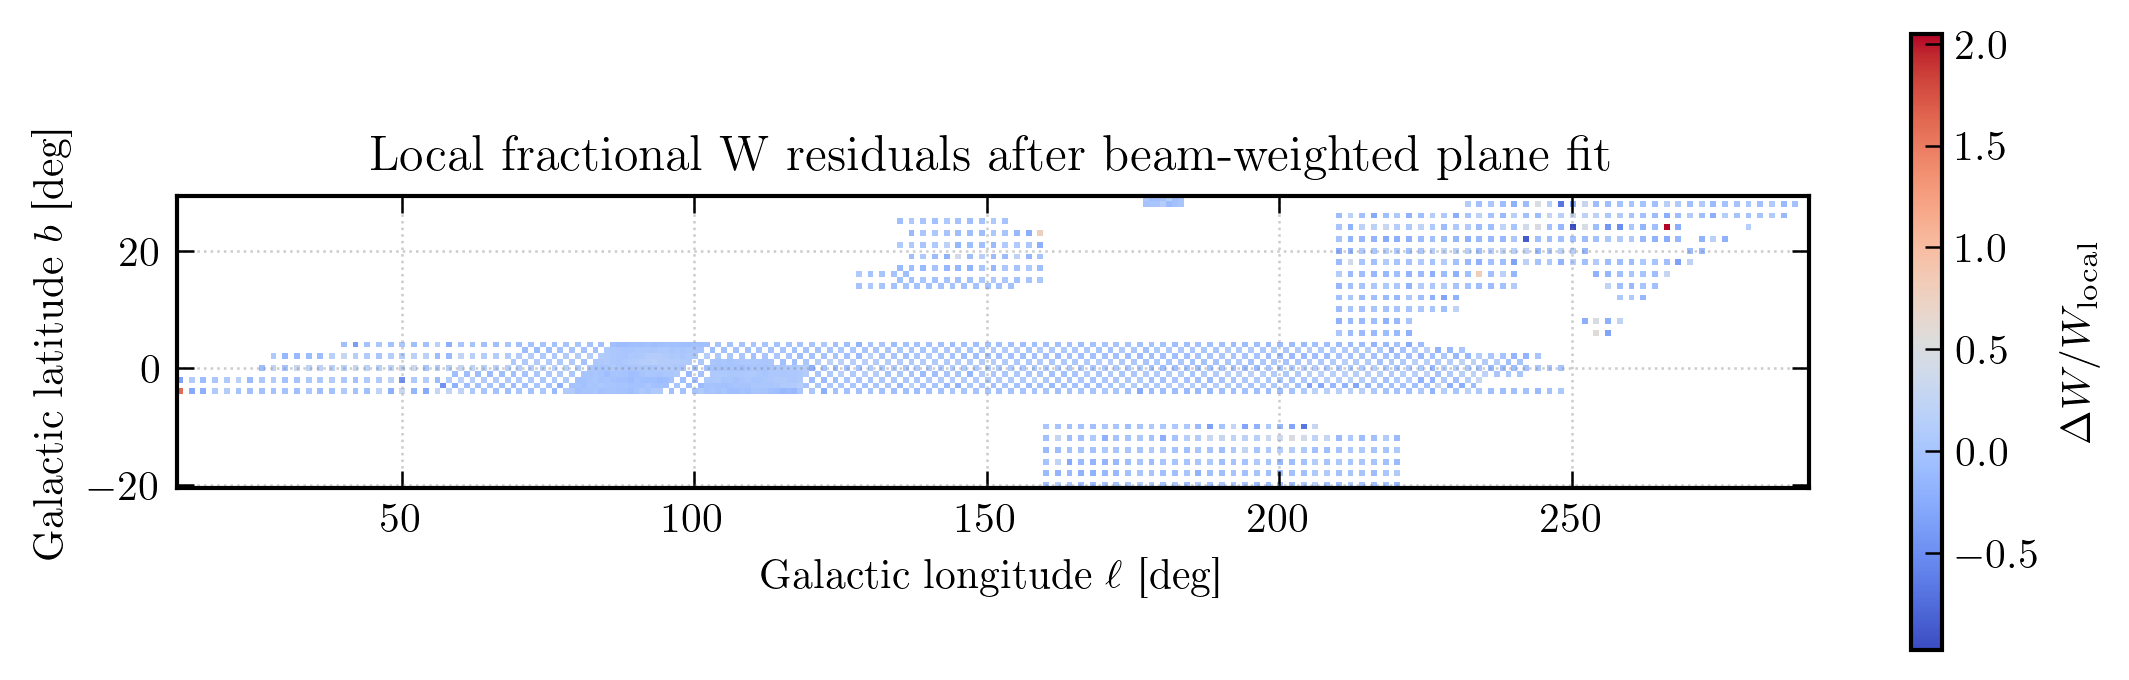

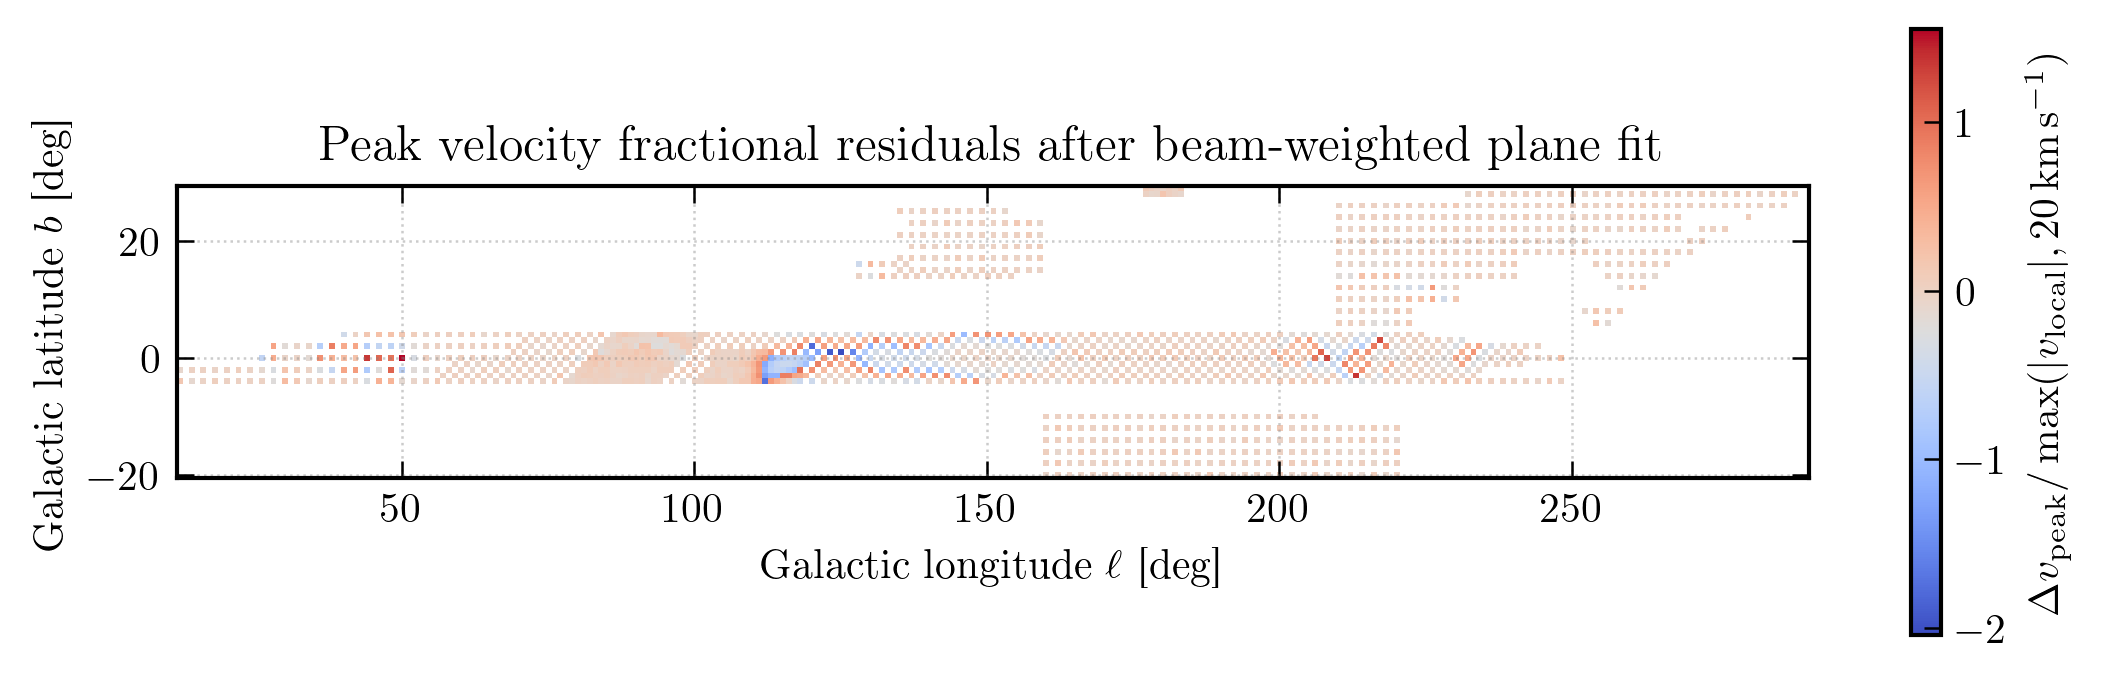

In [6]:
from scipy.signal import find_peaks

# Neighbor QA on the overlap-aligned survey grid.
# Use a beam-weighted local plane so smooth sky gradients are modeled out
# before flagging residual outliers.
HPBW_DEG = 3.4
NEIGHBOR_MAX_SEP_DEG = 4.5
MIN_NEIGHBORS = 5
W_Z_THRESH = 3.5
W_FRAC_THRESH = 0.30
W_SCALE_FLOOR = 5.0
PEAK_V_Z_THRESH = 4.0
PEAK_V_ABS_THRESH = 15.0
PEAK_V_MIN_SIGMA = 3.0
PEAK_V_SCALE_FLOOR = 20.0


def weighted_median(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values = values[valid]
    weights = weights[valid]
    if values.size == 0:
        return np.nan
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cdf = np.cumsum(weights)
    cutoff = 0.5 * cdf[-1]
    return values[np.searchsorted(cdf, cutoff)]


def weighted_mad(values, weights, center=None):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values = values[valid]
    weights = weights[valid]
    if values.size == 0:
        return np.nan
    if center is None:
        center = weighted_median(values, weights)
    return weighted_median(np.abs(values - center), weights)


def beam_overlap_weight(sep_deg, hpbw_deg=HPBW_DEG):
    # Normalized overlap of two identical Gaussian beams separated by sep_deg.
    return np.exp(-2.0 * np.log(2.0) * (sep_deg / hpbw_deg) ** 2)


def local_tangent_offsets(gl0, gb0, gl1, gb1):
    dl = ((gl1 - gl0 + 180.0) % 360.0) - 180.0
    db = gb1 - gb0
    x = dl * np.cos(np.deg2rad(0.5 * (gb0 + gb1)))
    y = db
    sep = np.hypot(x, y)
    return x, y, sep


def fit_weighted_local_plane(target_gl, target_gb, neighbors, value_key, sigma_floor=0.0):
    rows = []
    values = []
    weights = []

    for n in neighbors:
        value = n.get(value_key, np.nan)
        if not np.isfinite(value):
            continue
        x, y, sep = local_tangent_offsets(target_gl, target_gb, n['gl'], n['gb'])
        weight = beam_overlap_weight(sep)
        if not np.isfinite(weight) or weight <= 0:
            continue
        rows.append([1.0, x, y])
        values.append(value)
        weights.append(weight)

    if len(values) < 3:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

    design = np.asarray(rows, dtype=float)
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    weighted_design = design * np.sqrt(weights)[:, None]
    if np.linalg.matrix_rank(weighted_design) < 3:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

    coeffs, *_ = np.linalg.lstsq(weighted_design, values * np.sqrt(weights), rcond=None)
    predicted_center = coeffs[0]
    residuals = values - design @ coeffs
    resid_center = weighted_median(residuals, weights)
    resid_mad = weighted_mad(residuals, weights, resid_center)
    resid_sigma = max(resid_mad * 1.4826, sigma_floor)
    return predicted_center, coeffs, resid_sigma, residuals, weights, resid_center



# # ── Session-level spectral consistency ──────────────────────────────────
# # For cells with 2+ sessions, compare each session's R spectrum to the
# # channel-wise median.  Flag sessions whose broadband offset or narrowband
# # peak exceeds noise-based thresholds, then recompute the combined R
# # excluding the flagged sessions.
# #
# # broadband_z = |mean(residual)| / (noise_rms / sqrt(N_ch))
# # narrowband_z = max(|residual|) / noise_rms
#
# BROADBAND_Z_THRESH = 4.0
# NARROWBAND_Z_THRESH = 5.0
# NOISE_V_CUTOFF = -100.0   # km/s; channels below this are off-signal
#
# session_drop_log = []  # [(gl, gb, session_label, broadband_z, narrowband_z)]
#
# for (gl, gb), cr in list(cell_results_combined.items()):
#     R_per = cr.get('R_per_session')
#     labels = cr.get('session_labels')
#     pairs = cr.get('pairs_per_session')
#     if R_per is None or len(R_per) < 2:
#         continue
#
#     R_stack = np.array(R_per, dtype=float)  # (n_sessions, n_channels)
#
#     # Channel-wise median reference
#     with warnings.catch_warnings():
#         warnings.simplefilter('ignore', RuntimeWarning)
#         R_ref = np.nanmedian(R_stack, axis=0)
#
#     # Noise RMS from off-signal channels of the reference
#     noise_mask = v_lsr_overlap < NOISE_V_CUTOFF
#     noise_vals = R_ref[noise_mask]
#     noise_vals = noise_vals[np.isfinite(noise_vals)]
#     if noise_vals.size < 5:
#         continue
#     noise_rms = np.std(noise_vals)
#     if noise_rms <= 0 or not np.isfinite(noise_rms):
#         continue
#
#     n_ch = np.count_nonzero(np.isfinite(R_ref))
#     if n_ch < 8:
#         continue
#
#     keep_idx = []
#     for s_idx in range(len(R_per)):
#         resid = R_per[s_idx] - R_ref
#         finite = np.isfinite(resid)
#         if finite.sum() < 8:
#             keep_idx.append(s_idx)
#             continue
#
#         mean_resid = np.nanmean(resid)
#         broadband_z = abs(mean_resid) / (noise_rms / np.sqrt(finite.sum()))
#         narrowband_z = np.nanmax(np.abs(resid)) / noise_rms
#
#         if broadband_z > BROADBAND_Z_THRESH or narrowband_z > NARROWBAND_Z_THRESH:
#             session_drop_log.append((
#                 gl, gb, labels[s_idx] if labels else f'#{s_idx}',
#                 broadband_z, narrowband_z,
#             ))
#         else:
#             keep_idx.append(s_idx)
#
#     if len(keep_idx) < len(R_per) and len(keep_idx) > 0:
#         # Recompute combined R from surviving sessions
#         R_kept = np.array([R_per[i] for i in keep_idx], dtype=float)
#         with warnings.catch_warnings():
#             warnings.simplefilter('ignore', RuntimeWarning)
#             cr['R_overlap'] = np.nanmean(R_kept, axis=0)
#         cr['R_per_session'] = [R_per[i] for i in keep_idx]
#         cr['session_labels'] = [labels[i] for i in keep_idx] if labels else None
#         cr['pairs_per_session'] = [pairs[i] for i in keep_idx] if pairs else None
#         cr['n_sessions'] = len(keep_idx)
#         cr['n_pairs'] = sum(pairs[i] for i in keep_idx) if pairs else cr['n_pairs']
#         cr['sessions_dropped'] = len(R_per) - len(keep_idx)
#     elif len(keep_idx) == 0:
#         # All sessions bad -- flag entire cell by removing it
#         cr['sessions_dropped'] = len(R_per)
#         cr['all_sessions_flagged'] = True
#
# n_cells_affected = len(set((gl, gb) for gl, gb, *_ in session_drop_log))
# print(f'Session consistency: checked {sum(1 for cr in cell_results_combined.values() if cr.get("n_sessions", 1) >= 2)} multi-session cells')
# print(f'  Thresholds: broadband_z > {BROADBAND_Z_THRESH}, narrowband_z > {NARROWBAND_Z_THRESH}')
# print(f'  Dropped {len(session_drop_log)} sessions across {n_cells_affected} cells')
# if session_drop_log:
#     for gl, gb, lbl, bz, nz in sorted(session_drop_log)[:10]:
#         print(f'    l={gl:3d} b={gb:+3d} {lbl}: broadband_z={bz:.1f}, narrowband_z={nz:.1f}')
#     if len(session_drop_log) > 10:
#         print(f'    ... ({len(session_drop_log) - 10} more)')
#
# # Remove cells where all sessions were flagged
# all_bad_cells = {(gl, gb) for (gl, gb), cr in cell_results_combined.items()
#                  if cr.get('all_sessions_flagged')}
# for key in all_bad_cells:
#     del cell_results_combined[key]
# if all_bad_cells:
#     print(f'  Removed {len(all_bad_cells)} cells with ALL sessions flagged')

session_drop_log = []  # disabled -- sessions look consistent

cell_keys = list(cell_results_combined.keys())
cell_coords = np.array(cell_keys, dtype=float)
cell_metrics = {}

# First pass: compute per-cell W, peak_v, and noise estimates.
for gl, gb in cell_keys:
    cr = cell_results_combined[(gl, gb)]
    R = np.asarray(cr['R_overlap'], dtype=float)
    if R.ndim != 1 or R.size != len(v_lsr_overlap):
        continue

    finite = np.isfinite(R)
    n_valid_ch = int(np.count_nonzero(finite))
    if n_valid_ch < 8:
        continue

    R_work = R.copy()
    if n_valid_ch >= 2:
        chans = np.arange(R_work.size)
        R_work[~finite] = np.interp(chans[~finite], chans[finite], R_work[finite])
        W = np.sum(R_work) * dv_kms
    elif n_valid_ch == 1:
        W = R_work[finite][0] * dv_kms * R_work.size
    else:
        W = np.nan

    noise_mask = v_lsr_overlap < -100.0
    noise_vals = R[noise_mask]
    noise_vals = noise_vals[np.isfinite(noise_vals)]
    noise_rms = np.std(noise_vals) if noise_vals.size > 5 else np.nan

    signal_mask = (v_lsr_overlap >= -80.0) & (v_lsr_overlap <= 60.0)
    v_sig = v_lsr_overlap[signal_mask]
    R_sig = R[signal_mask]
    sig_valid = np.isfinite(R_sig)

    peak_R = np.nan
    peak_v = np.nan
    peak_prom = np.nan
    peak_count = 0

    if sig_valid.sum() >= 3:
        sig_idx = np.arange(R_sig.size)
        R_fill = R_sig.copy()
        R_fill[~sig_valid] = np.interp(sig_idx[~sig_valid], sig_idx[sig_valid], R_sig[sig_valid])

        kernel = np.ones(5) / 5.0
        R_smooth = np.convolve(R_fill, kernel, mode='same')

        distance = max(1, int(round(4.0 / dv_kms)))
        prominence = 2.5 * noise_rms if np.isfinite(noise_rms) and noise_rms > 0 else 0.0
        peaks, props = find_peaks(R_smooth, distance=distance, prominence=prominence)
        peak_count = len(peaks)

        if peak_count > 0:
            best = int(np.argmax(props['prominences']))
            peak_idx = int(peaks[best])
            peak_R = float(R_fill[peak_idx])
            peak_v = float(v_sig[peak_idx])
            peak_prom = float(props['prominences'][best])
        else:
            peak_idx = int(np.nanargmax(R_fill))
            peak_R = float(R_fill[peak_idx])
            peak_v = float(v_sig[peak_idx])

    snr = peak_R / noise_rms if np.isfinite(noise_rms) and noise_rms > 0 and np.isfinite(peak_R) else np.nan

    cell_metrics[(gl, gb)] = {
        'gl': gl,
        'gb': gb,
        'W': W,
        'peak_R': peak_R,
        'peak_v': peak_v,
        'peak_prom': peak_prom,
        'peak_count': peak_count,
        'snr': snr,
        'noise_rms': noise_rms,
        'n_pairs': cr['n_pairs'],
        'n_valid_ch': n_valid_ch,
    }


# Second pass: compare each cell to its beam-weighted local plane.
neighbor_cells = []
for gl, gb in cell_keys:
    cell = cell_metrics.get((gl, gb))
    if cell is None:
        continue

    dl = ((cell_coords[:, 0] - gl + 180.0) % 360.0) - 180.0
    db = cell_coords[:, 1] - gb
    x = dl * np.cos(np.deg2rad(0.5 * (cell_coords[:, 1] + gb)))
    sep = np.hypot(x, db)
    neighbor_indices = np.where((sep > 0) & (sep <= NEIGHBOR_MAX_SEP_DEG))[0]

    neighbors = []
    for j in neighbor_indices:
        neighbor_gl, neighbor_gb = cell_keys[j]
        neighbor_cell = cell_metrics.get((neighbor_gl, neighbor_gb))
        if neighbor_cell is None:
            continue
        neighbors.append({
            'gl': neighbor_gl,
            'gb': neighbor_gb,
            'W': neighbor_cell['W'],
            'peak_v': neighbor_cell['peak_v'],
        })

    cell['neighbor_count'] = len(neighbors)
    if len(neighbors) < MIN_NEIGHBORS:
        cell['W_local_pred'] = np.nan
        cell['W_resid'] = np.nan
        cell['W_frac_resid'] = np.nan
        cell['W_sigma'] = np.nan
        cell['W_z'] = np.nan
        cell['W_grad_l'] = np.nan
        cell['W_grad_b'] = np.nan
        cell['peak_v_local_pred'] = np.nan
        cell['peak_v_resid'] = np.nan
        cell['peak_v_frac_resid'] = np.nan
        cell['peak_v_abs_resid'] = np.nan
        cell['peak_v_sigma'] = np.nan
        cell['peak_v_z'] = np.nan
        cell['peak_v_grad_l'] = np.nan
        cell['peak_v_grad_b'] = np.nan
        cell['W_flag'] = False
        cell['peak_v_flag'] = False
        neighbor_cells.append(cell)
        continue

    W_sigma_floor = max(1e-6, cell['noise_rms'] * dv_kms * np.sqrt(cell['n_valid_ch'])) if np.isfinite(cell['noise_rms']) else 1e-6
    W_pred, W_coeffs, W_sigma, W_neighbor_residuals, W_neighbor_weights, W_resid_center = fit_weighted_local_plane(
        gl, gb, neighbors, 'W', sigma_floor=W_sigma_floor
    )
    pv_pred, pv_coeffs, pv_sigma, pv_neighbor_residuals, pv_neighbor_weights, pv_resid_center = fit_weighted_local_plane(
        gl, gb, neighbors, 'peak_v', sigma_floor=PEAK_V_MIN_SIGMA
    )

    cell['W_local_pred'] = W_pred
    cell['W_resid'] = cell['W'] - W_pred if np.isfinite(cell['W']) and np.isfinite(W_pred) else np.nan
    W_scale = max(abs(W_pred), W_SCALE_FLOOR)
    cell['W_frac_resid'] = cell['W_resid'] / W_scale if np.isfinite(cell['W_resid']) else np.nan
    cell['W_sigma'] = W_sigma
    cell['W_z'] = cell['W_resid'] / W_sigma if np.isfinite(cell['W_resid']) and np.isfinite(W_sigma) and W_sigma > 0 else np.nan
    cell['W_grad_l'] = W_coeffs[1] if np.ndim(W_coeffs) > 0 and len(W_coeffs) > 1 else np.nan
    cell['W_grad_b'] = W_coeffs[2] if np.ndim(W_coeffs) > 0 and len(W_coeffs) > 2 else np.nan

    cell['peak_v_local_pred'] = pv_pred
    cell['peak_v_resid'] = cell['peak_v'] - pv_pred if np.isfinite(cell['peak_v']) and np.isfinite(pv_pred) else np.nan
    peak_v_scale = max(abs(pv_pred), PEAK_V_SCALE_FLOOR)
    cell['peak_v_frac_resid'] = cell['peak_v_resid'] / peak_v_scale if np.isfinite(cell['peak_v_resid']) else np.nan
    cell['peak_v_abs_resid'] = abs(cell['peak_v_resid']) if np.isfinite(cell['peak_v_resid']) else np.nan
    cell['peak_v_sigma'] = pv_sigma
    cell['peak_v_z'] = cell['peak_v_resid'] / pv_sigma if np.isfinite(cell['peak_v_resid']) and np.isfinite(pv_sigma) and pv_sigma > 0 else np.nan
    cell['peak_v_grad_l'] = pv_coeffs[1] if np.ndim(pv_coeffs) > 0 and len(pv_coeffs) > 1 else np.nan
    cell['peak_v_grad_b'] = pv_coeffs[2] if np.ndim(pv_coeffs) > 0 and len(pv_coeffs) > 2 else np.nan

    cell['W_flag'] = (
        np.isfinite(cell['W_frac_resid'])
        and abs(cell['W_frac_resid']) > W_FRAC_THRESH
        and np.isfinite(cell['W_z'])
        and abs(cell['W_z']) > W_Z_THRESH
    )
    cell['peak_v_flag'] = (
        np.isfinite(cell['peak_v_abs_resid'])
        and cell['peak_v_abs_resid'] > PEAK_V_ABS_THRESH
        and np.isfinite(cell['peak_v_z'])
        and abs(cell['peak_v_z']) > PEAK_V_Z_THRESH
    )

    neighbor_cells.append(cell)


neighbor_flagged = [c for c in neighbor_cells if c['W_flag'] or c['peak_v_flag']]
neighbor_w_flag_count = sum(1 for c in neighbor_cells if c['W_flag'])
neighbor_peak_flag_count = sum(1 for c in neighbor_cells if c['peak_v_flag'])
neighbor_any_flag_count = len(neighbor_flagged)

print(f'Neighbor diagnostics: {len(neighbor_cells)} cells')
print(f'  Using the overlap window with {len(v_lsr_overlap)} channels and dv={dv_kms:.3f} km/s')
print(f'  Neighborhood: cells within {NEIGHBOR_MAX_SEP_DEG:.1f} deg, min neighbors={MIN_NEIGHBORS}')
print(f'  Beam weight: Gaussian overlap with HPBW={HPBW_DEG:.1f} deg')
print(f'  Thresholds: |dW/W_local| > {W_FRAC_THRESH:.0%} and |z_W| > {W_Z_THRESH:.1f}; '
      f'|dv_peak| > {PEAK_V_ABS_THRESH:.0f} km/s and |z_v| > {PEAK_V_Z_THRESH:.1f}')
print(f'  Flags: W={neighbor_w_flag_count}, peak_v={neighbor_peak_flag_count}, any={neighbor_any_flag_count}')

if neighbor_flagged:
    print('  Most deviant cells:')

    def severity(cell):
        w_score = abs(cell['W_frac_resid']) if np.isfinite(cell['W_frac_resid']) else 0.0
        v_score = abs(cell['peak_v_z']) if np.isfinite(cell['peak_v_z']) else 0.0
        return max(w_score, v_score)

    for cell in sorted(neighbor_flagged, key=severity, reverse=True)[:12]:
        print(
            f"    l={cell['gl']:3d} b={cell['gb']:3d} "
            f"W={cell['W']:+.3f} (frac={cell['W_frac_resid']:+.2f}, z={cell['W_z']:+.2f}) "
            f"v_peak={cell['peak_v']:+.1f} km/s "
            f"(dv={cell['peak_v_resid']:+.1f}, z={cell['peak_v_z']:+.2f}) "
            f"n={cell['neighbor_count']}"
        )


gl = np.array([c['gl'] for c in neighbor_cells], dtype=float)
gb = np.array([c['gb'] for c in neighbor_cells], dtype=float)
w_frac = np.array([c['W_frac_resid'] for c in neighbor_cells], dtype=float)
peak_v_frac_resid = np.array([c['peak_v_frac_resid'] for c in neighbor_cells], dtype=float)
peak_v_z = np.array([c['peak_v_z'] for c in neighbor_cells], dtype=float)

fig, ax = plot_heatmap(
    gl, gb, w_frac,
    cbar_label=r"$\Delta W / W_{\mathrm{local}}$",
    cmap="coolwarm",
    title="Local fractional W residuals after beam-weighted plane fit",
)
plt.show()

fig, ax = plot_heatmap(
    gl, gb, peak_v_frac_resid,
    cbar_label=r"$\Delta v_{\mathrm{peak}} / \max(|v_{\mathrm{local}}|, 20\,\mathrm{km\,s^{-1}})$",
    cmap="coolwarm",
    title="Peak velocity fractional residuals after beam-weighted plane fit",
)
plt.show()

In [7]:
# # --- Diagnostic: per-session R spectra for cells with dropped sessions ---
# if session_drop_log:
#     affected_cells = sorted(set((gl, gb) for gl, gb, *_ in session_drop_log))
#     dropped_sessions = defaultdict(set)
#     for gl, gb, lbl, bz, nz in session_drop_log:
#         dropped_sessions[(gl, gb)].add(lbl)
#
#     NCOLS = 5
#     n_panels = len(affected_cells)
#     nrows = math.ceil(n_panels / NCOLS)
#     ROW_HEIGHT_IN = 1.8
#
#     fig, axes = plt.subplots(
#         nrows, NCOLS,
#         figsize=(plotting.TEXTWIDTH_IN, ROW_HEIGHT_IN * nrows),
#         gridspec_kw={'hspace': 0.6, 'wspace': 0.3},
#     )
#     axes = np.atleast_2d(axes)
#
#     for i, (gl, gb) in enumerate(affected_cells):
#         ri, ci = divmod(i, NCOLS)
#         ax = axes[ri, ci]
#
#         orig = session_qa_originals.get((gl, gb))
#         if orig is None:
#             ax.set_visible(False)
#             continue
#
#         R_per = orig['R_per_session']
#         labels = orig['session_labels']
#         dropped = dropped_sessions[(gl, gb)]
#
#         with warnings.catch_warnings():
#             warnings.simplefilter('ignore', RuntimeWarning)
#             R_ref = np.nanmedian(np.array(R_per, dtype=float), axis=0)
#
#         ax.plot(v_lsr_overlap, R_ref, lw=plotting.LW_STANDARD,
#                 color='k', alpha=plotting.ALPHA_STANDARD, zorder=10)
#
#         cmap_tab = plt.cm.tab10
#         for s_idx, R_s in enumerate(R_per):
#             lbl = labels[s_idx] if labels else f'#{s_idx}'
#             is_dropped = lbl in dropped
#             color = cmap_tab(s_idx % 10)
#             ax.plot(v_lsr_overlap, R_s,
#                     lw=plotting.LW_LIGHT if is_dropped else plotting.LW_FINE,
#                     ls='--' if is_dropped else '-',
#                     color=color,
#                     alpha=plotting.ALPHA_STANDARD if is_dropped else plotting.ALPHA_LIGHT,
#                     zorder=5 if is_dropped else 2)
#
#         plotting.zero_line(ax)
#         ax.set_title(
#             rf'$\ell$={gl} $b$={gb:+d}',
#             fontsize=plotting.TICK_SIZE - 3, pad=2,
#         )
#         ax.tick_params(labelsize=plotting.TICK_SIZE - 4)
#         if ri < nrows - 1:
#             ax.set_xticklabels([])
#         if ci == 0:
#             ax.set_ylabel(r'$R$', fontsize=plotting.TICK_SIZE - 3)
#
#     for i in range(n_panels, nrows * NCOLS):
#         ri, ci = divmod(i, NCOLS)
#         axes[ri, ci].set_visible(False)
#
#     n_last_row = n_panels % NCOLS or NCOLS
#     for ci in range(min(NCOLS, n_last_row)):
#         axes[-1, ci].set_xlabel(r'$v_{\mathrm{LSR}}$ [km\,s$^{-1}$]',
#                                  fontsize=plotting.TICK_SIZE - 3)
#
#     fig.suptitle(
#         f'Session-inconsistent cells (black = median, dashed = dropped) '
#         f'--- {len(session_drop_log)} sessions across {len(affected_cells)} cells',
#         fontsize=plotting.EMPHASIS_SIZE,
#     )
#     fig.tight_layout()
#     plt.show()
# else:
#     print('No session-inconsistent cells to plot.')

/tmp/ipykernel_1838/870028505.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


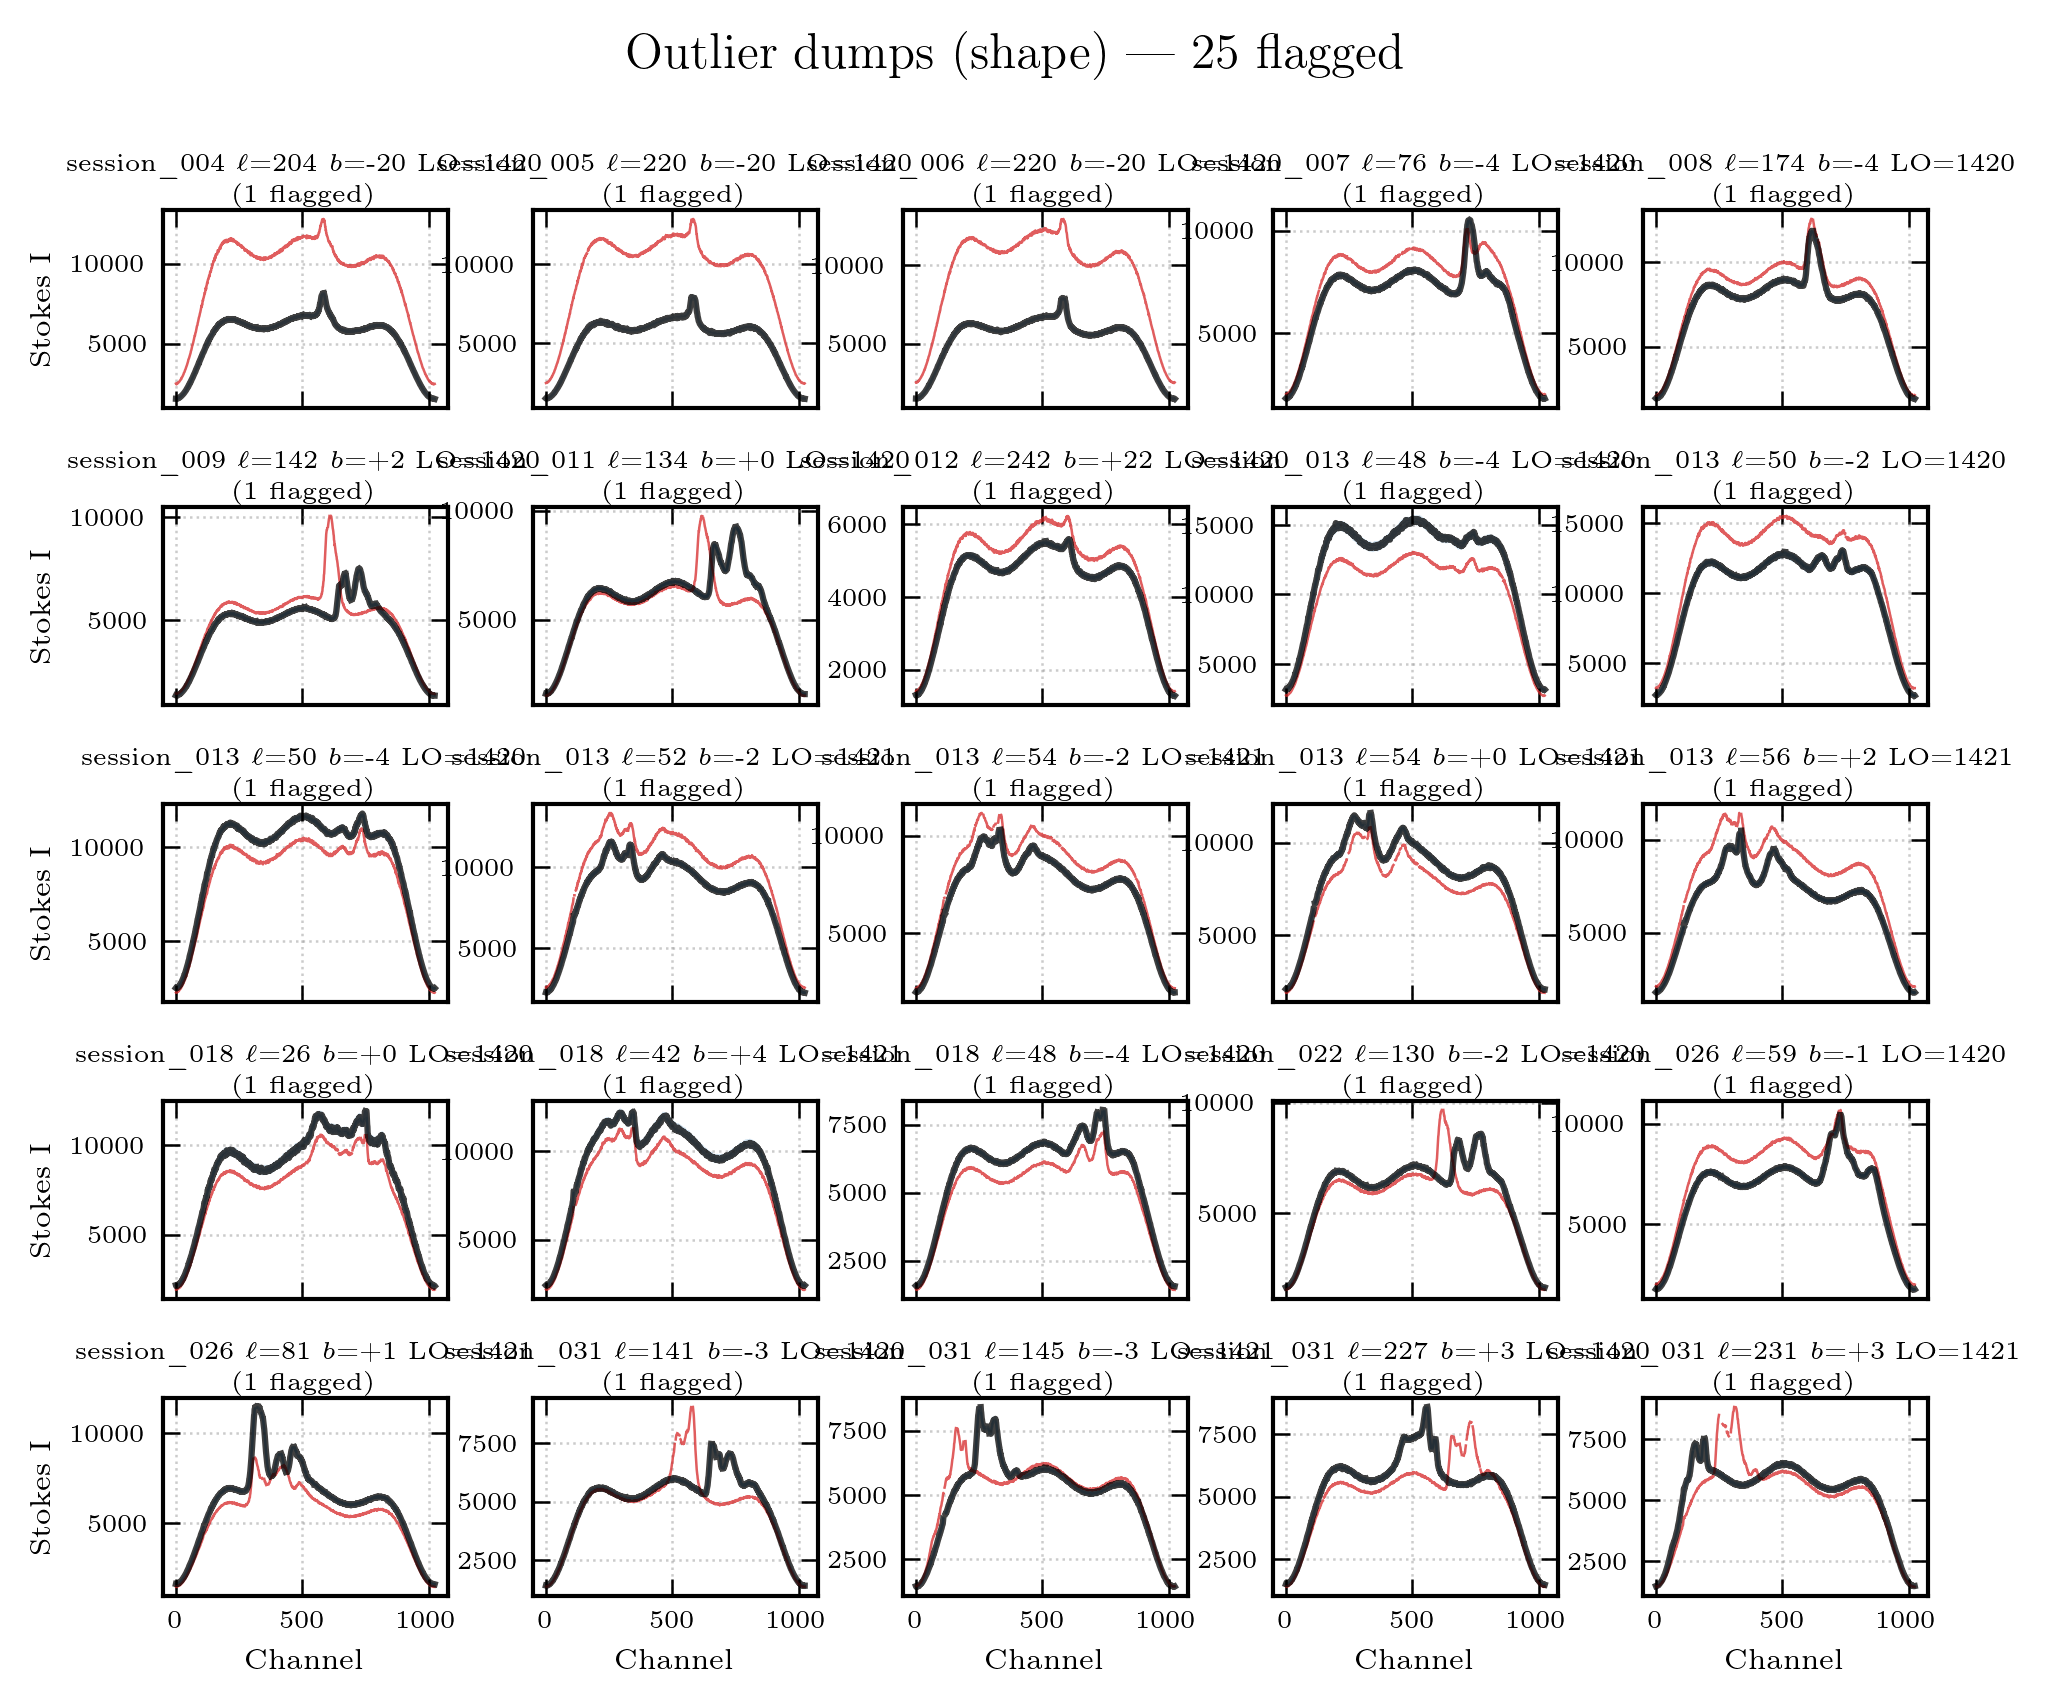

In [8]:
# --- Diagnostic: overplot all dumps per (cell, LO) with outliers highlighted ---
all_sci = [r for r in records if r.get('gl') is not None and not r['noise_on']]
all_sci += outlier_records
outlier_paths = set(id(r) for r in outlier_records)

plot_groups = defaultdict(list)
for r in all_sci:
    plot_groups[(r['session'], r['target'], r['lo_mhz'])].append(r)

groups_with_outliers = {
    k: v for k, v in plot_groups.items()
    if any(id(r) in outlier_paths for r in v)
}

if groups_with_outliers:
    NCOLS = 5
    keys = sorted(groups_with_outliers.keys())
    n_panels = len(keys)
    nrows = math.ceil(n_panels / NCOLS)
    ROW_HEIGHT_IN = 1.2
    rows_per_page = max(1, int(plotting.A4_USABLE_HEIGHT_IN / ROW_HEIGHT_IN))
    channels = np.arange(NFFT)

    def _resolve_lb(group):
        r0 = group[0]
        c = ac.SkyCoord(ra=r0['ra'] * u_ast.deg, dec=r0['dec'] * u_ast.deg, frame='icrs')
        return round(c.galactic.l.deg), round(c.galactic.b.deg)

    for page_start_row in range(0, nrows, rows_per_page):
        page_end_row = min(page_start_row + rows_per_page, nrows)
        page_nrows = page_end_row - page_start_row
        page_start_idx = page_start_row * NCOLS
        page_end_idx = min(page_end_row * NCOLS, n_panels)

        fig, axes = plt.subplots(
            page_nrows, NCOLS,
            figsize=(plotting.TEXTWIDTH_IN, ROW_HEIGHT_IN * page_nrows),
            gridspec_kw={'hspace': 0.5, 'wspace': 0.3},
        )
        axes = np.atleast_2d(axes)

        for i_in_page, i_global in enumerate(range(page_start_idx, page_end_idx)):
            dr, target, lo = keys[i_global]
            group = groups_with_outliers[keys[i_global]]
            ri, ci = divmod(i_in_page, NCOLS)
            ax = axes[ri, ci]

            good = [r['stokes_I'] for r in group if id(r) not in outlier_paths]
            if good:
                with warnings.catch_warnings():
                    warnings.simplefilter('ignore', RuntimeWarning)
                    med_spec = np.nanmedian(np.array(good), axis=0)
                ax.plot(channels, med_spec, lw=plotting.LW_STANDARD,
                        color='k', alpha=plotting.ALPHA_STANDARD, zorder=10)

            for r in group:
                is_outlier = id(r) in outlier_paths
                ax.plot(channels, r['stokes_I'],
                        lw=plotting.LW_FINE,
                        color='C3' if is_outlier else 'C0',
                        alpha=plotting.ALPHA_STANDARD if is_outlier else plotting.ALPHA_EXTRA_LIGHT,
                        zorder=5 if is_outlier else 1)

            gl, gb = _resolve_lb(group)
            n_out = sum(1 for r in group if id(r) in outlier_paths)
            ax.set_title(
                rf'{dr} $\ell$={gl} $b$={gb:+d} LO={lo:.0f}'
                f'\n({n_out} flagged)',
                fontsize=plotting.TICK_SIZE - 4, pad=2,
            )
            ax.tick_params(labelsize=plotting.TICK_SIZE - 4)
            if ri < page_nrows - 1:
                ax.set_xticklabels([])
            if ci == 0:
                ax.set_ylabel('Stokes I', fontsize=plotting.TICK_SIZE - 3)

        n_on_page = page_end_idx - page_start_idx
        for i_in_page in range(n_on_page, page_nrows * NCOLS):
            ri, ci = divmod(i_in_page, NCOLS)
            axes[ri, ci].set_visible(False)

        for ci in range(min(NCOLS, n_on_page)):
            axes[-1, ci].set_xlabel('Channel', fontsize=plotting.TICK_SIZE - 3)

        page_num = page_start_row // rows_per_page + 1
        total_pages = math.ceil(nrows / rows_per_page)
        label = f'Outlier dumps (shape) --- {n_outlier_removed} flagged'
        if total_pages > 1:
            label += f' ({page_num}/{total_pages})'
        fig.suptitle(label, fontsize=plotting.EMPHASIS_SIZE)
        fig.tight_layout()
        plt.show()
else:
    print('No outlier dumps to plot.')

## 3. Pointing summary

In [9]:
import pandas as pd

pointing_stats = {}

for r in records:
    if r.get('gl') is None:
        continue
    key = (r['gl'], r['gb'])
    if key not in pointing_stats:
        pointing_stats[key] = {'n_captured': 0, 'bad_pixels': 0, 'unusable': 0}

    pointing_stats[key]['n_captured'] += 1
    n_bad = int(np.sum(np.isnan(r['stokes_I'])))
    pointing_stats[key]['bad_pixels'] += n_bad
    if n_bad > NFFT // 2:
        pointing_stats[key]['unusable'] += 1

rows_df = []
for (gl, gb), stats in sorted(pointing_stats.items()):
    rows_df.append({
        'l': gl, 'b': gb,
        'captured': stats['n_captured'],
        'bad_pixels_total': stats['bad_pixels'],
        'unusable_dumps': stats['unusable'],
    })

df = pd.DataFrame(rows_df).set_index(['l', 'b'])

n_pointings = len(df)
n_unusable_any = (df['unusable_dumps'] > 0).sum()
print(f'Unique pointings: {n_pointings}')
print(f'Total dumps: {df["captured"].sum()}')
print(f'Pointings with any unusable dumps: {n_unusable_any}')
print(f'Mean bad pixels per dump: {df["bad_pixels_total"].sum() / df["captured"].sum():.0f} / {NFFT}')
print()
df

Unique pointings: 1585
Total dumps: 13289
Pointings with any unusable dumps: 0
Mean bad pixels per dump: 88 / 1024



captured  bad_pixels_total  unusable_dumps
l   b                                              
12  -4          8               285               0
    -2          8               331               0
14  -4          8               301               0
    -2          8               304               0
16  -4          8               315               0
...           ...               ...             ...
284  28         8               253               0
286  26         8               368               0
     28         8               302               0
288  28         8               374               0
290  28         9               403               0

[1585 rows x 3 columns]

## 4. Survey coverage + observability

Mollweide projection showing survey pointings colored by dump count,
overlaid on candidate survey footprints and the never-observable region.

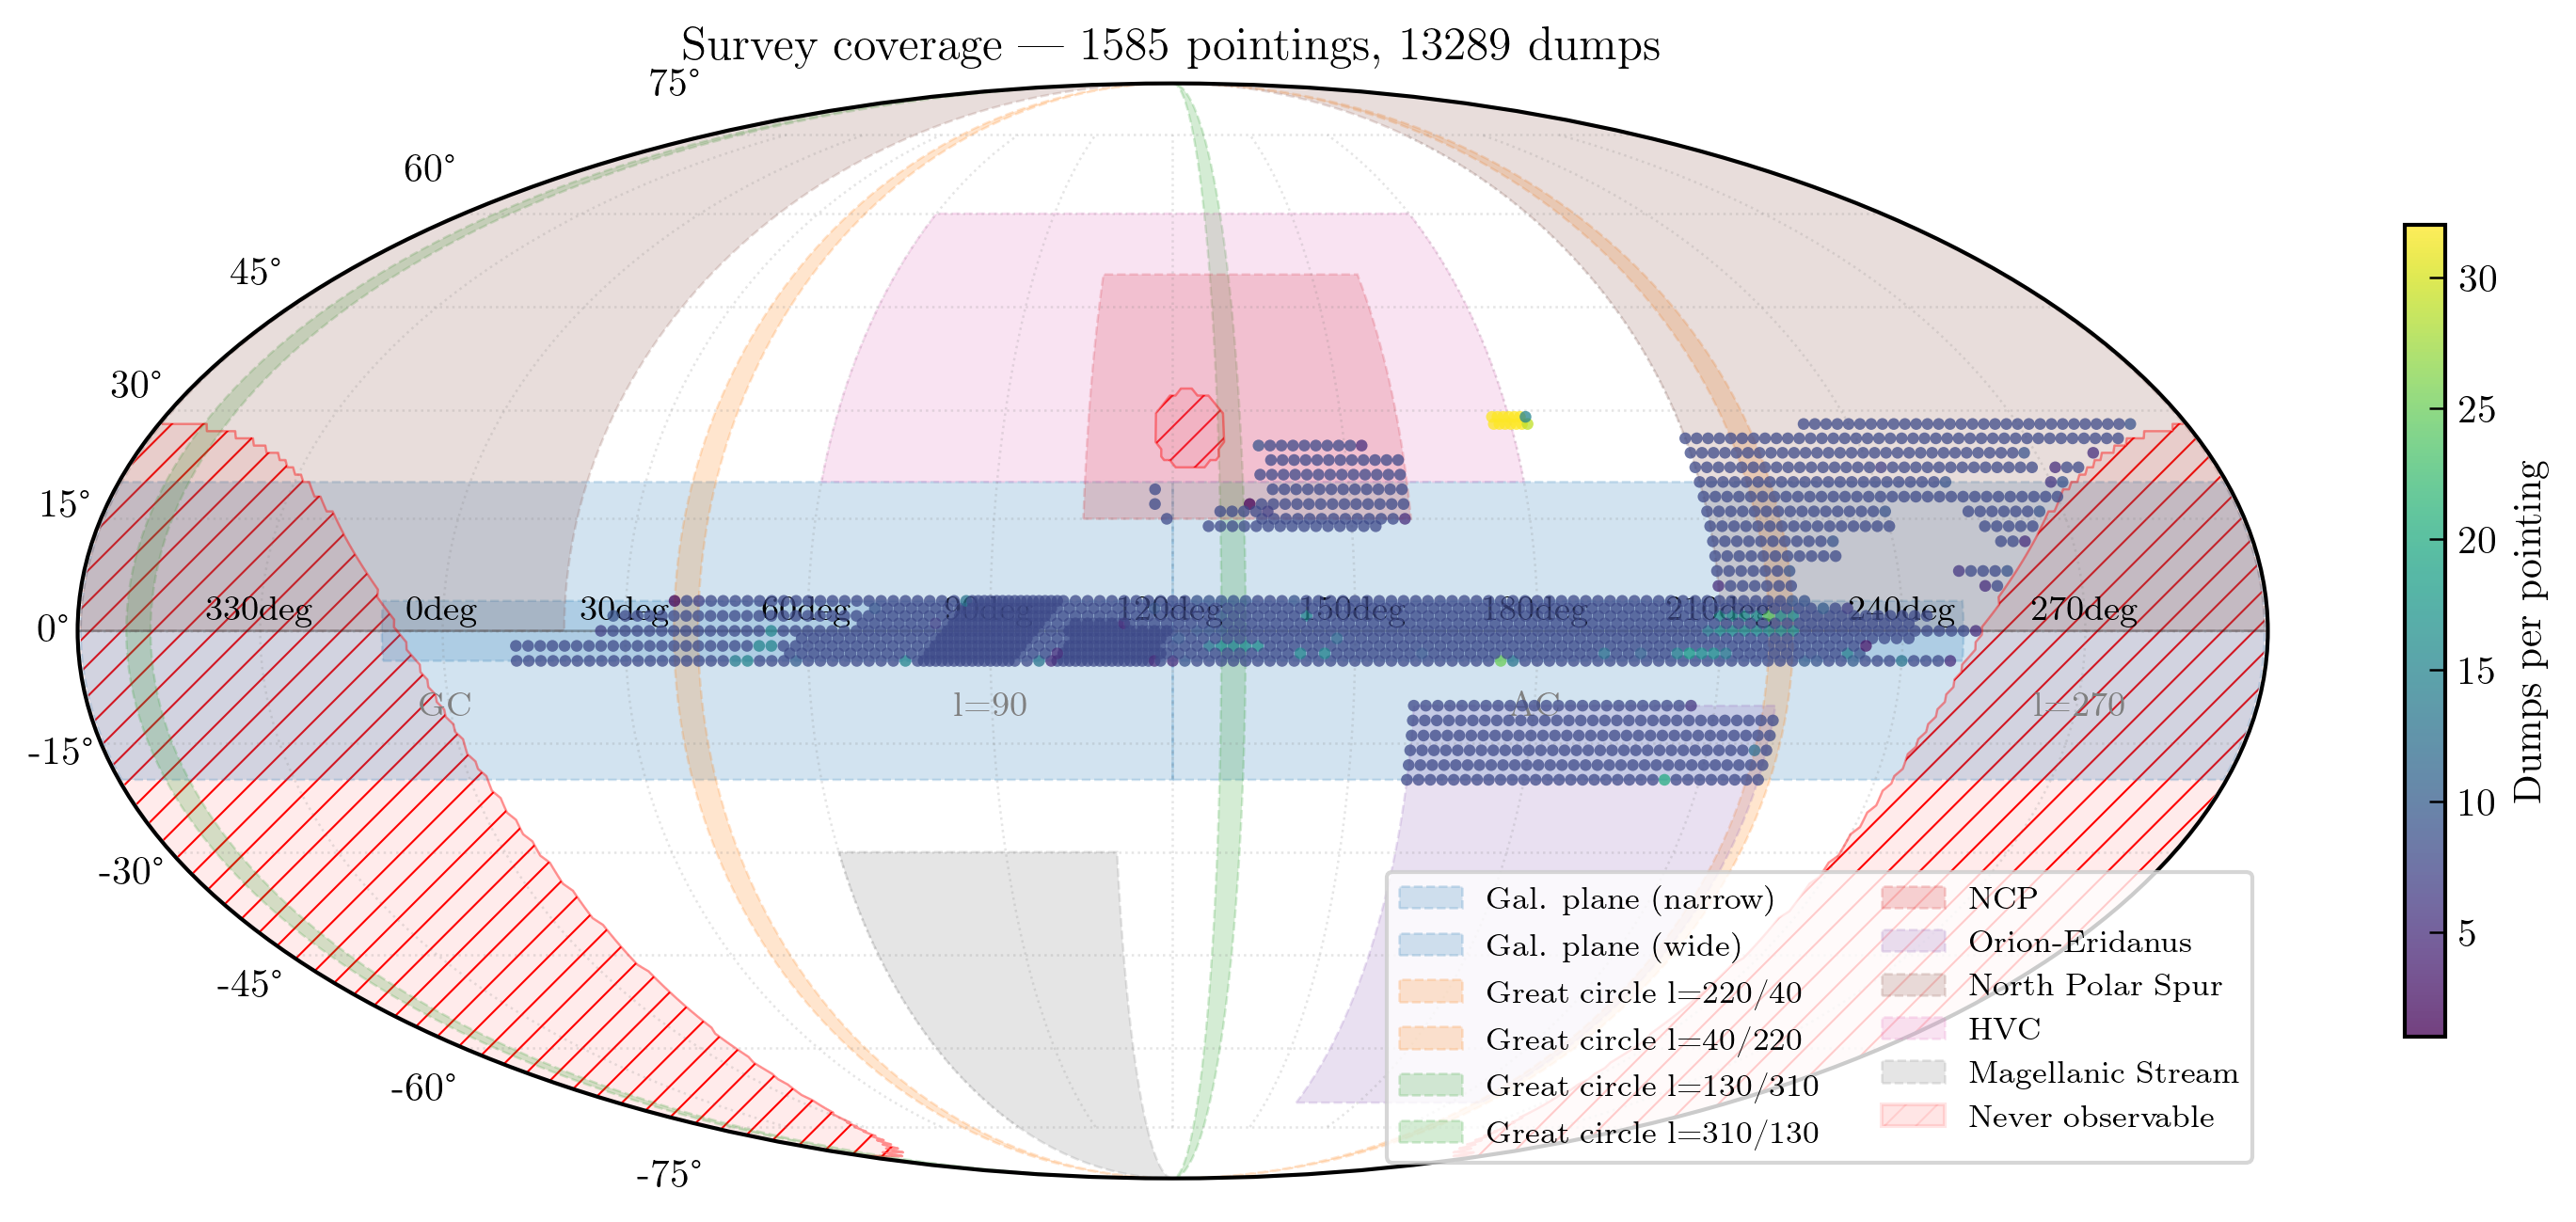

In [10]:
from matplotlib.patches import Rectangle
import matplotlib as mpl

LEO_LAT = 37.9183
MOLL_CENTER_L = 120.0
MOLL_SEAM = (MOLL_CENTER_L + 180) % 360
MIN_ALT, MAX_ALT = 17.0, 83.0
AZ_MIN, AZ_MAX = 7.0, 348.0

# Candidate survey footprints (from 01_scan_plan)
projects_raw = [
    ('Gal. plane (narrow)',     -10, 250,   -4,   4, 'C0'),
    ('Gal. plane (wide)',         0, 360,  -20,  20, 'C0'),
    ('Great circle l=220/40',   218, 222,  -90,  90, 'C1'),
    ('Great circle l=40/220',    38,  42,  -90,  90, 'C1'),
    ('Great circle l=130/310',  128, 132,  -90,  90, 'C2'),
    ('Great circle l=310/130',  308, 312,  -90,  90, 'C2'),
    ('NCP',                     105, 160,   15,  50, 'C3'),
    ('Orion-Eridanus',          160, 220,  -70, -10, 'C4'),
    ('North Polar Spur',        210, 380,    0,  90, 'C5'),
    ('HVC',                      60, 180,   20,  60, 'C6'),
    ('Magellanic Stream',        60, 110,  -90, -30, 'C7'),
]

def _normalize_l(l):
    return l % 360

def _crosses_seam(l_min, l_max):
    span = l_max - l_min
    if span >= 360:
        return True
    ln = _normalize_l(l_min)
    lx = _normalize_l(l_max)
    if ln <= lx:
        return ln < MOLL_SEAM < lx
    else:
        return MOLL_SEAM > ln or MOLL_SEAM < lx

projects = []
for name, l_min, l_max, b_min, b_max, color in projects_raw:
    if l_max - l_min >= 360:
        projects.append((name, MOLL_SEAM + 0.5, MOLL_SEAM + 180, b_min, b_max, color))
        projects.append((name, MOLL_SEAM + 180, MOLL_SEAM + 359.5, b_min, b_max, color))
    elif _crosses_seam(l_min, l_max):
        projects.append((name, l_min, MOLL_SEAM - 0.5, b_min, b_max, color))
        projects.append((name, MOLL_SEAM + 0.5, l_max, b_min, b_max, color))
    else:
        projects.append((name, l_min, l_max, b_min, b_max, color))

def _wrap_l(l):
    l = l - MOLL_CENTER_L
    if l > 180: l -= 360
    if l < -180: l += 360
    return l

def _make_rect(l_min, l_max, b_min, b_max):
    n = 50
    wl_min, wl_max = _wrap_l(l_min), _wrap_l(l_max)
    if wl_min > wl_max:
        return None
    l_bot = np.linspace(wl_min, wl_max, n)
    l_top = np.linspace(wl_max, wl_min, n)
    b_left = np.linspace(b_min, b_max, n)
    b_right = np.linspace(b_max, b_min, n)
    ls = np.concatenate([l_bot, np.full(n, wl_max), l_top, np.full(n, wl_min)])
    bs = np.concatenate([np.full(n, b_min), b_left, np.full(n, b_max), b_right])
    return np.column_stack([np.deg2rad(ls), np.deg2rad(bs)])

# Never-observable mask
l_dense = np.arange(-179.5, 180.5, 1.0)
b_dense = np.arange(-89.5, 90.5, 1.0)
L_dense, B_dense = np.meshgrid(l_dense, b_dense)
L_true = (L_dense + MOLL_CENTER_L) % 360

gc_grid = ac.SkyCoord(l=L_true.ravel() * u_ast.deg, b=B_dense.ravel() * u_ast.deg,
                      frame='galactic')
dec_rad = np.deg2rad(gc_grid.transform_to(ac.ICRS()).dec.deg).reshape(L_dense.shape)
lat_rad = np.deg2rad(LEO_LAT)

ha_steps = np.deg2rad(np.arange(0, 360, 1))
observable = np.zeros(L_dense.shape, dtype=bool)
alt_lo_r, alt_hi_r = np.deg2rad(MIN_ALT), np.deg2rad(MAX_ALT)
az_lo_r, az_hi_r = np.deg2rad(AZ_MIN), np.deg2rad(AZ_MAX)

for ha in ha_steps:
    sin_alt = (np.sin(lat_rad) * np.sin(dec_rad)
               + np.cos(lat_rad) * np.cos(dec_rad) * np.cos(ha))
    alt = np.arcsin(np.clip(sin_alt, -1, 1))
    cos_az_num = np.sin(dec_rad) - np.sin(lat_rad) * sin_alt
    cos_az_den = np.cos(lat_rad) * np.cos(alt)
    with np.errstate(invalid='ignore', divide='ignore'):
        cos_az = np.clip(cos_az_num / cos_az_den, -1, 1)
    az = np.arccos(cos_az)
    az = np.where(np.sin(ha) > 0, 2 * np.pi - az, az)
    observable |= ((alt >= alt_lo_r) & (alt <= alt_hi_r)
                   & (az >= az_lo_r) & (az <= az_hi_r))

inacc_mask = (~observable).astype(float)

# Collect (l, b) and dump counts per pointing
gl_pts = np.array([k[0] for k in pointing_stats])
gb_pts = np.array([k[1] for k in pointing_stats])
n_dumps = np.array([v['n_captured'] for v in pointing_stats.values()])

# --- Plot ---
fig, _ax = plotting.landscapewidth_figure(5)
_ax.remove()
ax = fig.add_subplot(111, projection='mollweide')
ax.grid(True, alpha=plotting.ALPHA_EXTRA_LIGHT)

l_line = np.linspace(-np.pi, np.pi, 500)
ax.plot(l_line, np.zeros_like(l_line), 'k-', lw=plotting.LW_FINE, alpha=0.3)

mpl.rcParams['hatch.color'] = 'red'
mpl.rcParams['hatch.linewidth'] = 0.5
ax.contourf(np.deg2rad(L_dense), np.deg2rad(B_dense), inacc_mask,
            levels=[0.5, 1.5], colors=['red'], alpha=0.08, hatches=['///'], zorder=1)
ax.contour(np.deg2rad(L_dense), np.deg2rad(B_dense), inacc_mask,
           levels=[0.5], colors=['red'], linewidths=0.6, alpha=0.4, zorder=2)
mpl.rcParams['hatch.color'] = 'black'

plotted_labels = set()
for name, l_min, l_max, b_min, b_max, color in projects:
    verts = _make_rect(l_min, l_max, b_min, b_max)
    if verts is not None:
        label = name if name not in plotted_labels else None
        poly = plt.Polygon(verts, alpha=plotting.ALPHA_EXTRA_LIGHT,
                           facecolor=color, edgecolor=color,
                           lw=plotting.LW_FINE, linestyle='--', label=label)
        ax.add_patch(poly)
        if label:
            plotted_labels.add(name)

gl_wrap = np.array([_wrap_l(l) for l in gl_pts])
sc = ax.scatter(np.deg2rad(gl_wrap), np.deg2rad(gb_pts),
                c=n_dumps, cmap='viridis', s=SS_FINE,
                edgecolors='none', alpha=plotting.ALPHA_STANDARD, zorder=5)
cbar = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.05)
cbar.set_label('Dumps per pointing', fontsize=plotting.LABEL_SIZE)

tick_locs = np.arange(-150, 180, 30)
tick_labels = [f'{int((t + MOLL_CENTER_L) % 360)}deg' for t in tick_locs]
ax.set_xticks(np.deg2rad(tick_locs))
ax.set_xticklabels(tick_labels, fontsize=plotting.LEGEND_SIZE)

for ld, name in [(0, 'GC'), (90, 'l=90'), (180, 'AC'), (270, 'l=270')]:
    lp = _wrap_l(ld)
    if -180 <= lp <= 180:
        ax.annotate(name, (np.deg2rad(lp), np.deg2rad(-8)),
                    fontsize=plotting.LEGEND_SIZE, ha='center', va='top', color='gray')

ax.set_title(f'Survey coverage --- {n_pointings} pointings, {N} dumps',
             fontsize=plotting.EMPHASIS_SIZE)

legend_proxy = Rectangle((0, 0), 1, 1, facecolor='red', alpha=0.1,
                          edgecolor='red', hatch='///')
handles, labels = ax.get_legend_handles_labels()
handles.append(legend_proxy)
labels.append('Never observable')
ax.legend(handles, labels, fontsize=plotting.LEGEND_SIZE - 1, loc='lower right', ncol=2)

fig.tight_layout()
plt.show()

## 5. Pointing traces per DR

Scan pattern in galactic coordinates and alt/az Mollweide showing the
actual telescope path through each dump, colored by LST.

In [11]:
# from matplotlib.patches import Circle

# HPBW_DEG = 3.4
# LEO_LON = -122.1067

# for dr in sessions:
#     dr_recs = sorted([r for r in records if r['session'] == dr and r.get('gl') is not None],
#                      key=lambda r: r['time'])
#     if len(dr_recs) < 2:
#         continue

#     gl_dr = np.array([r['gl'] for r in dr_recs], dtype=float)
#     gb_dr = np.array([r['gb'] for r in dr_recs], dtype=float)
#     alt_dr = np.array([r['alt'] for r in dr_recs])
#     az_dr = np.array([r['az'] for r in dr_recs])
#     t_dr = np.array([r['time'] for r in dr_recs])

#     lst_hrs = np.array([
#         AstroTime(t, format='unix').sidereal_time(
#             'apparent', longitude=LEO_LON * u_ast.deg
#         ).hour for t in t_dr
#     ])

#     # --- Galactic scan pattern ---
#     fig, ax = plt.subplots(figsize=(plotting.TEXTWIDTH_IN, 4))
#     vmin, vmax = lst_hrs.min(), lst_hrs.max()
#     norm = plt.Normalize(vmin=vmin, vmax=vmax)
#     cmap = plt.cm.viridis

#     for i in range(len(gl_dr)):
#         beam = Circle((gl_dr[i], gb_dr[i]), HPBW_DEG / 2,
#                        fill=False, edgecolor=cmap(norm(lst_hrs[i])),
#                        alpha=plotting.ALPHA_EXTRA_LIGHT, lw=plotting.LW_FINE)
#         ax.add_patch(beam)

#     sc = ax.scatter(gl_dr, gb_dr, c=lst_hrs, cmap='viridis',
#                     s=plotting.SS_FINE, edgecolors='none',
#                     alpha=plotting.ALPHA_STANDARD, zorder=5,
#                     vmin=vmin, vmax=vmax)
#     ax.plot(gl_dr, gb_dr, lw=plotting.LW_FINE * 0.3, color='k',
#             alpha=0.15, zorder=0)
#     ax.set_xlabel(r'$\ell$ [deg]', fontsize=plotting.LABEL_SIZE)
#     ax.set_ylabel(r'$b$ [deg]', fontsize=plotting.LABEL_SIZE)
#     ax.set_title(f'{dr} scan pattern (HPBW = {HPBW_DEG}deg)', fontsize=plotting.EMPHASIS_SIZE)
#     ax.set_aspect('equal')
#     ax.grid(True, **plotting.GRID_STYLE)
#     cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
#     cbar.set_label('LST [hr]')
#     fig.tight_layout()
#     plt.show()

#     # --- Alt/Az Mollweide ---
#     az_moll = np.where(az_dr > 180, az_dr - 360, az_dr)

#     fig, _ax = plotting.landscapewidth_figure(5)
#     _ax.remove()
#     ax = fig.add_subplot(111, projection='mollweide')
#     ax.grid(True, **{k: v for k, v in plotting.GRID_STYLE.items() if k != 'color'},
#             color=plotting.NEUTRAL_COLOR)

#     az_line = np.linspace(-np.pi, np.pi, 500)
#     ax.plot(az_line, np.full_like(az_line, np.deg2rad(17)),
#             lw=plotting.LW_LIGHT, ls='--', color='C3', alpha=plotting.ALPHA_LIGHT)
#     for az_lim in [7, 348]:
#         az_l = az_lim if az_lim <= 180 else az_lim - 360
#         ax.axvline(np.deg2rad(az_l), lw=plotting.LW_LIGHT, ls='--',
#                    color='C1', alpha=plotting.ALPHA_LIGHT)

#     ax.plot(np.deg2rad(az_moll), np.deg2rad(alt_dr),
#             lw=plotting.LW_FINE * 0.5, color='k', alpha=0.2, zorder=0)
#     sc = ax.scatter(np.deg2rad(az_moll), np.deg2rad(alt_dr),
#                     c=lst_hrs, cmap='viridis', s=plotting.SS_FINE,
#                     edgecolors='none', alpha=plotting.ALPHA_STANDARD, zorder=5,
#                     vmin=vmin, vmax=vmax)

#     for azd, name in [(0, 'N'), (90, 'E'), (180, 'S'), (-90, 'W')]:
#         ax.annotate(name, (np.deg2rad(azd), np.deg2rad(-2)),
#                     fontsize=plotting.TICK_SIZE, ha='center', va='top',
#                     fontweight='bold', color=plotting.NEUTRAL_COLOR)

#     ax.set_title(f'{dr} alt/az trace', fontsize=plotting.EMPHASIS_SIZE)
#     cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
#     cbar.set_label('LST [hr]')
#     fig.tight_layout()
#     plt.show()

#     print(f'{dr}: {len(dr_recs)} dumps, LST {lst_hrs.min():.1f}-{lst_hrs.max():.1f} hr, '
#           f'alt [{alt_dr.min():.0f}-{alt_dr.max():.0f}], az [{az_dr.min():.0f}-{az_dr.max():.0f}]')

## 6. Update survey manifest

Write per-pointing completeness to `survey_manifest.json`.
Push this file to the observation Pi so `observe_otf.py` can skip complete cells.

In [12]:
from manifest import write_manifest, read_manifest

# Exclude QA-flagged cells from manifest counts
flagged_pointings = set()
if 'neighbor_cells' in dir():
    flagged_pointings = {(c['gl'], c['gb']) for c in neighbor_cells
                         if c.get('W_flag') or c.get('peak_v_flag')}
if 'session_drop_log' in dir() and session_drop_log:
    session_flagged = {(gl, gb) for gl, gb, *_ in session_drop_log}
    flagged_pointings |= session_flagged
    print(f'Excluding {len(session_flagged)} cells with dropped sessions from manifest')
    if flagged_pointings:
        print(f'Excluding {len(flagged_pointings)} QA-flagged cells from manifest')

manifest_pointings = {}
for r in records:
    if r.get('gl') is None or r['noise_on']:
        continue
    key = (r['gl'], r['gb'])
    if key in flagged_pointings:
        continue
    if key not in manifest_pointings:
        manifest_pointings[key] = {'n_1420': 0, 'n_1421': 0}
    if r['lo_mhz'] == 1420.0:
        manifest_pointings[key]['n_1420'] += 1
    elif r['lo_mhz'] == 1421.0:
        manifest_pointings[key]['n_1421'] += 1

MANIFEST_PATH = Path('../survey_manifest.json')
write_manifest(manifest_pointings, MANIFEST_PATH)

pointings = read_manifest(MANIFEST_PATH)
incomplete = {lb: info for lb, info in pointings.items() if not info['complete']}
if incomplete:
    print(f'\nIncomplete cells ({len(incomplete)}):')
    print(f'  {"l":>4} {"b":>4} {"pairs":>5} {"target":>6} {"need":>5}')
    for (l, b), info in sorted(incomplete.items()):
        need = info['target'] - info['n_pairs']
        print(f'  {l:>4} {b:>+4} {info["n_pairs"]:>5} {info["target"]:>6} {need:>5}')
else:
    print('\nAll cells complete!')


Manifest written: ../survey_manifest.json
  1565 pointings: 1540 complete, 25 incomplete

Incomplete cells (25):
     l    b pairs target  need
    26   +0     3      4     1
    38   +4     0      4     4
    42   +4     3      4     1
    81   +1     3      4     1
   100   -4     2      4     2
   101   -3     2      4     2
   112   +1     2      4     2
   117   -4     2      4     2
   120   -4     2      4     2
   133  +17     0      4     4
   136  +16     3      4     1
   153  +25     2      4     2
   159  +15     2      4     2
   206  -10     3      4     1
   210   +6     2      4     2
   231   +3     3      4     1
   234   -2     1      4     3
   248   -4     2      4     2
   250   +8     2      4     2
   252   +0     2      4     2
   254   +6     2      4     2
   262  +12     2      4     2
   270  +20     3      4     1
   272  +22     2      4     2
   280  +24     2      4     2
